In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded")



Libraries loaded


In [3]:
n = 1000  # 1000 loans

loans = pd.DataFrame({
    'loan_id': [f'LOAN_{i:04d}' for i in range(1, n+1)],
    'loan_amount': np.random.randint(10000, 500000, n),
    'outstanding_balance': np.random.uniform(0.5, 1.0, n),
    'loan_type': np.random.choice(['Mortgage', 'Personal', 'Auto', 'SME'], n),
    'days_past_due': np.random.choice([0, 15, 45, 90, 120], n, 
                                       p=[0.60, 0.15, 0.10, 0.10, 0.05]),
    'original_pd': np.random.uniform(0.01, 0.30, n),
    'lgd': np.random.uniform(0.20, 0.80, n),
    'remaining_term_months': np.random.randint(1, 360, n),
    'collateral_value': np.random.randint(0, 600000, n),
    'sector': np.random.choice(['Real Estate', 'Retail', 'Manufacturing', 
                                 'Services', 'Government'], n)
})

# EAD = outstanding balance % × loan amount
loans['ead'] = loans['outstanding_balance'] * loans['loan_amount']

print(loans.shape)
print(loans.head())

(1000, 11)
     loan_id  loan_amount  outstanding_balance loan_type  days_past_due  \
0  LOAN_0001       131958             0.528188      Auto              0   
1  LOAN_0002       156867             0.932361       SME             15   
2  LOAN_0003       141932             0.906451      Auto              0   
3  LOAN_0004       375838             0.999859       SME              0   
4  LOAN_0005       269178             0.998318       SME              0   

   original_pd       lgd  remaining_term_months  collateral_value  \
0     0.204729  0.642771                    122            231807   
1     0.193362  0.416285                    145             24363   
2     0.067708  0.602762                    223            308838   
3     0.131317  0.362386                    257            394798   
4     0.227773  0.248738                    268            336473   

        sector            ead  
0       Retail   69698.598894  
1     Services  146256.702498  
2  Real Estate  128654.3330

In [4]:
def assign_stage(days_past_due):
    if days_past_due == 0:
        return 1
    elif days_past_due <= 30:
        return 2
    elif days_past_due <= 89:
        return 2
    else:
        return 3

loans['stage'] = loans['days_past_due'].apply(assign_stage)

print(loans['stage'].value_counts())

stage
1    592
2    258
3    150
Name: count, dtype: int64


In [5]:
def calculate_pd(row):
    if row['stage'] == 1:
        # 12-month PD
        return row['original_pd']
    elif row['stage'] == 2:
        # Lifetime PD — scale up by remaining term
        return 1 - (1 - row['original_pd']) ** (row['remaining_term_months'] / 12)
    else:
        # Stage 3 — default already occurred
        return 1.0

loans['pd'] = loans.apply(calculate_pd, axis=1)

print(loans[['loan_id', 'stage', 'original_pd', 'pd']].head(10))

     loan_id  stage  original_pd        pd
0  LOAN_0001      1     0.204729  0.204729
1  LOAN_0002      2     0.193362  0.925464
2  LOAN_0003      1     0.067708  0.067708
3  LOAN_0004      1     0.131317  0.131317
4  LOAN_0005      1     0.227773  0.227773
5  LOAN_0006      3     0.039398  1.000000
6  LOAN_0007      2     0.090577  0.031153
7  LOAN_0008      1     0.090133  0.090133
8  LOAN_0009      1     0.135285  0.135285
9  LOAN_0010      1     0.294307  0.294307


In [6]:

# ECL = PD × LGD × EAD
loans['ecl'] = loans['pd'] * loans['lgd'] * loans['ead']

# Summary by stage
ecl_summary = loans.groupby('stage').agg(
    Total_Loans=('loan_id', 'count'),
    Total_EAD=('ead', 'sum'),
    Total_ECL=('ecl', 'sum'),
    Avg_PD=('pd', 'mean'),
    Avg_LGD=('lgd', 'mean')
).round(2)

print(ecl_summary)

       Total_Loans     Total_EAD    Total_ECL  Avg_PD  Avg_LGD
stage                                                         
1              592  1.084977e+08   8487168.46    0.15     0.50
2              258  5.011588e+07  16725716.74    0.70     0.47
3              150  2.847936e+07  14427940.18    1.00     0.51


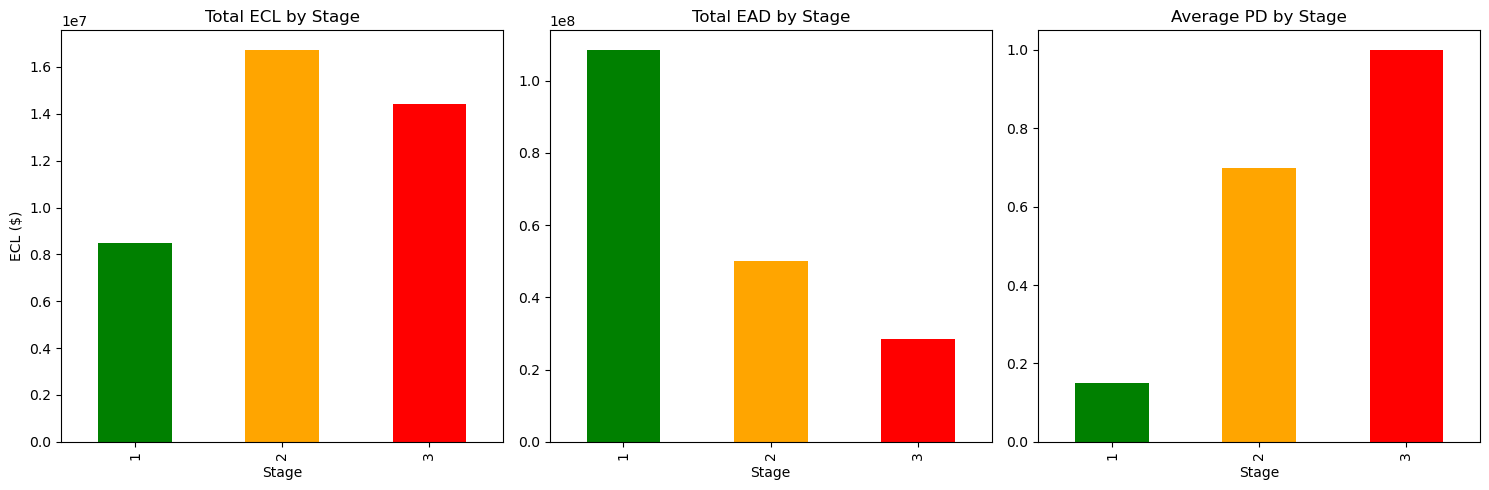

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ECL by Stage
ecl_summary['Total_ECL'].plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
axes[0].set_title('Total ECL by Stage')
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('ECL ($)')

# EAD by Stage
ecl_summary['Total_EAD'].plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
axes[1].set_title('Total EAD by Stage')
axes[1].set_xlabel('Stage')

# Average PD by Stage
ecl_summary['Avg_PD'].plot(kind='bar', ax=axes[2], color=['green', 'orange', 'red'])
axes[2].set_title('Average PD by Stage')
axes[2].set_xlabel('Stage')

plt.tight_layout()
plt.savefig('../outputs/ecl_by_stage.png')
plt.show()

In [8]:
# SAMA provisioning minimums
sama_minimums = {1: 0.01, 2: 0.05, 3: 0.20}

loans['sama_minimum_provision'] = loans['stage'].map(sama_minimums) * loans['ead']
loans['sama_flag'] = loans['ecl'] < loans['sama_minimum_provision']

print(f"Loans below SAMA minimum: {loans['sama_flag'].sum()}")
print(f"Additional provision needed: ${(loans['sama_minimum_provision'] - loans['ecl']).clip(0).sum():,.2f}")

Loans below SAMA minimum: 32
Additional provision needed: $60,147.77


In [9]:
sector_ecl = loans.groupby('sector').agg(
    Total_ECL=('ecl', 'sum'),
    Total_EAD=('ead', 'sum'),
    Loan_Count=('loan_id', 'count')
).round(2)

sector_ecl['ECL_Rate'] = (sector_ecl['Total_ECL'] / sector_ecl['Total_EAD'] * 100).round(2)
sector_ecl = sector_ecl.sort_values('Total_ECL', ascending=False)

print(sector_ecl)

                Total_ECL    Total_EAD  Loan_Count  ECL_Rate
sector                                                      
Services       8446643.99  36134408.08         189     23.38
Retail         8435787.77  40074951.88         209     21.05
Real Estate    8160015.19  43096210.96         227     18.93
Government     7709850.58  33947807.72         187     22.71
Manufacturing  6888527.84  33839517.23         188     20.36


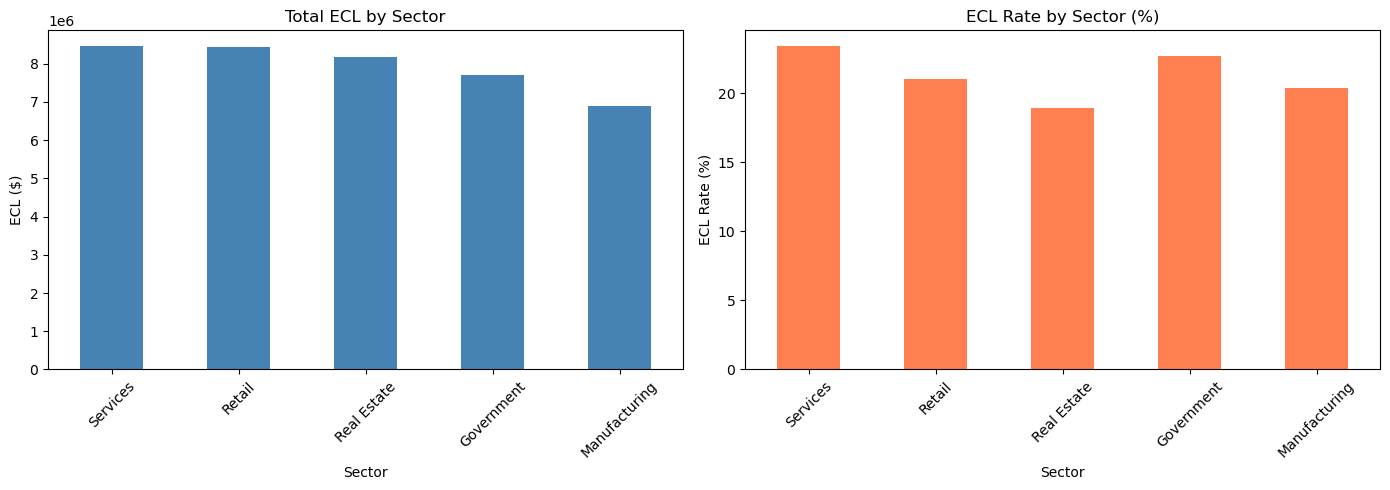

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ECL by Sector
sector_ecl['Total_ECL'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total ECL by Sector')
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('ECL ($)')
axes[0].tick_params(axis='x', rotation=45)

# ECL Rate by Sector
sector_ecl['ECL_Rate'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('ECL Rate by Sector (%)')
axes[1].set_xlabel('Sector')
axes[1].set_ylabel('ECL Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/ecl_by_sector.png')
plt.show()

In [11]:
with pd.ExcelWriter('../outputs/ecl_report.xlsx', engine='openpyxl') as writer:
    loans.to_excel(writer, sheet_name='Loan Portfolio', index=False)
    ecl_summary.to_excel(writer, sheet_name='ECL by Stage')
    sector_ecl.to_excel(writer, sheet_name='ECL by Sector')
    
    # SAMA flagged loans
    loans[loans['sama_flag']].to_excel(writer, sheet_name='SAMA Flags', index=False)

print("ECL report exported successfully")

ECL report exported successfully


In [12]:
# Stress scenarios
scenarios = {
    'Base Case': 1.0,
    'Mild Stress': 1.20,
    'Moderate Stress': 1.50,
    'Severe Stress': 2.0
}

stress_results = {}

for scenario, multiplier in scenarios.items():
    stressed_pd = (loans['pd'] * multiplier).clip(0, 1)
    stressed_ecl = stressed_pd * loans['lgd'] * loans['ead']
    stress_results[scenario] = {
        'Total_ECL': stressed_ecl.sum(),
        'ECL_Change_%': ((stressed_ecl.sum() / loans['ecl'].sum()) - 1) * 100
    }

stress_df = pd.DataFrame(stress_results).T.round(2)
print(stress_df)

                   Total_ECL  ECL_Change_%
Base Case        39640825.37          0.00
Mild Stress      43084059.19          8.69
Moderate Stress  46853914.83         18.20
Severe Stress    52221499.05         31.74


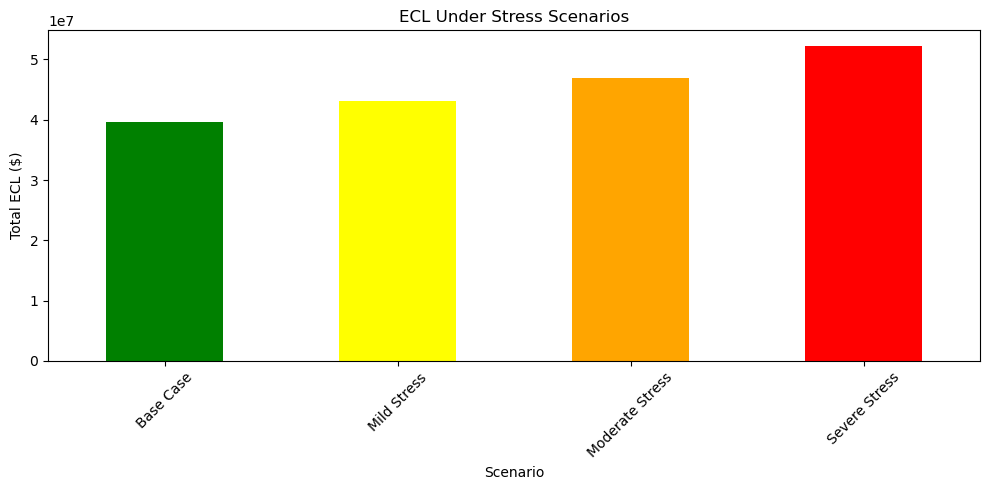

In [13]:
plt.figure(figsize=(10, 5))
stress_df['Total_ECL'].plot(kind='bar', 
    color=['green', 'yellow', 'orange', 'red'])
plt.title('ECL Under Stress Scenarios')
plt.xlabel('Scenario')
plt.ylabel('Total ECL ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/stress_testing.png')
plt.show()

In [15]:
with pd.ExcelWriter('../outputs/ecl_report.xlsx', engine='openpyxl') as writer:
    loans.to_excel(writer, sheet_name='Loan Portfolio', index=False)
    ecl_summary.to_excel(writer, sheet_name='ECL by Stage')
    sector_ecl.to_excel(writer, sheet_name='ECL by Sector')
    loans[loans['sama_flag']].to_excel(writer, sheet_name='SAMA Flags', index=False)
    stress_df.to_excel(writer, sheet_name='Stress Testing')

print("Updated ECL report exported successfully")

Updated ECL report exported successfully
